In [6]:
! pip install -r requirements.txt

  Using cached tensorflow-2.21.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (4.4 kB)
  Using cached keras-3.14.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached wrapt-2.1.2-cp312-cp312-macosx_11_0_arm64.wh

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math

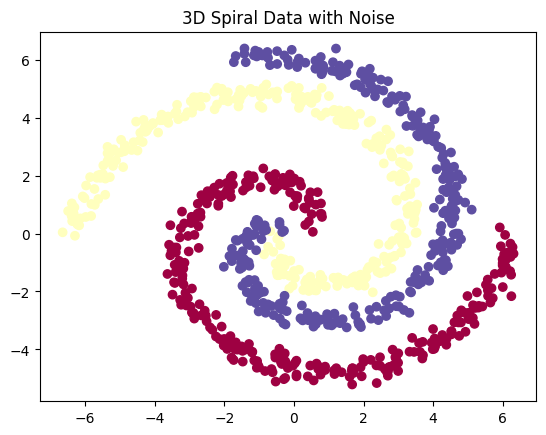

In [4]:
import numpy as np
import matplotlib.pyplot as plt


def generate_spiral_data(points, noise=0.5):
    n = points // 3  # Divide points equally among three spirals
    theta = np.sqrt(np.random.rand(n)) * 2 * np.pi  # Angle for spiral

    # Generate first spiral
    x1 = np.cos(theta) * theta
    y1 = np.sin(theta) * theta
    x1 += np.random.normal(scale=noise, size=n)
    y1 += np.random.normal(scale=noise, size=n)

    # Generate second spiral
    x2 = -np.cos(theta) * theta
    y2 = -np.sin(theta) * theta
    x2 += np.random.normal(scale=noise, size=n)
    y2 += np.random.normal(scale=noise, size=n)

    # Generate third spiral
    # Offset the angle for the third spiral
    x3 = np.cos(theta + np.pi/1.7) * theta
    y3 = np.sin(theta + np.pi/1.7) * theta
    x3 += np.random.normal(scale=noise, size=n)
    y3 += np.random.normal(scale=noise, size=n)

    # Combine the points and create labels
    X = np.vstack((np.vstack((x1, y1)).T,
                   np.vstack((x2, y2)).T,
                   np.vstack((x3, y3)).T))
    Y = np.hstack((np.zeros(n), np.ones(n), np.full(n, 2)))

    return X, Y


# Generate the data
points = 900  # Ensure the total number of points is divisible by 3
noise = 0.2
X, Y = generate_spiral_data(points, noise)

# Plot the data
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.Spectral)
plt.title("3D Spiral Data with Noise")
plt.show()

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(32, activation='relu', input_shape=(2,)),
    Dense(10, activation='relu'),
    Dense(3, activation="softmax"),
    
])

/Users/suyashmishra/miniconda3/envs/aiml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
from tensorflow.keras.utils import to_categorical
y = to_categorical(Y, num_classes=3)

In [14]:
from tensorflow.keras.callbacks import Callback

class CustomCallback(Callback):
    def on_epoch_end(self, epoch, logs = None):
        if epoch%25==0:
            print(f"epoch {epoch+1} : finished with logs: {logs}")

model.compile(loss='binary_crossentropy', metrics=['accuracy'])

# model.fit(X, y, epochs=150, batch_size=150, callbacks=[CustomCallback()])
model.fit(X, y, epochs=150, batch_size=150)

Epoch 1/150


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9889 - loss: 0.0570  
Epoch 2/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0564
Epoch 3/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9889 - loss: 0.0552
Epoch 4/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9878 - loss: 0.0549
Epoch 5/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9878 - loss: 0.0542
Epoch 6/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9878 - loss: 0.0539
Epoch 7/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9878 - loss: 0.0535
Epoch 8/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9867 - loss: 0.0527
Epoch 9/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9889 - loss: 0.0523
Epoch 10/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9889 - loss: 0.0519
Epoch 11/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9900 - loss: 0.0517
Epoch 12/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9889 - loss: 0.0510
Epoch 13/15

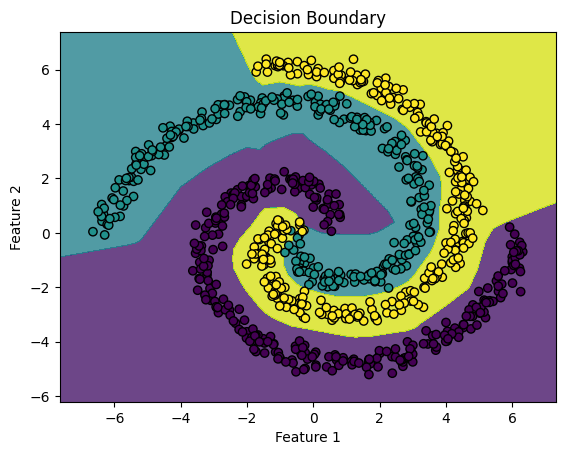

In [17]:
import numpy as np
import matplotlib.pyplot as plt

h = 0.01
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid_points, verbose=0)
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary')
plt.show()